**GAN**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
latent_dim = 100
batch_size = 128
lr = 0.0002
epochs = 50
beta1 = 0.5
beta2 = 0.999
image_size = 28*28

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.0MB/s]


In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(-1, 1, 28, 28)
        return img

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img = img.view(img.size(0), -1)
        out = self.model(img)
        return out

In [9]:
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

In [10]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))

In [11]:
def show_images(images, epoch):
    images = images.detach().cpu()
    grid = images[:25]

    fig, axs = plt.subplots(5,5, figsize=(5,5))
    idx = 0
    for i in range(5):
        for j in range(5):
            axs[i,j].imshow(grid[idx].squeeze(), cmap='gray')
            axs[i,j].axis('off')
            idx += 1

    plt.suptitle(f"epoch {epoch}")
    plt.show()

epoch=[1/50]  ,Disc Loss: 2.1811,  Gen loss: 1.0167
epoch=[2/50]  ,Disc Loss: 0.2566,  Gen loss: 4.2924
epoch=[3/50]  ,Disc Loss: 1.1079,  Gen loss: 3.3162
epoch=[4/50]  ,Disc Loss: 0.3818,  Gen loss: 2.5759
epoch=[5/50]  ,Disc Loss: 0.3663,  Gen loss: 2.9434
epoch=[6/50]  ,Disc Loss: 0.4186,  Gen loss: 2.4597
epoch=[7/50]  ,Disc Loss: 0.4908,  Gen loss: 1.7431
epoch=[8/50]  ,Disc Loss: 0.6512,  Gen loss: 1.7050
epoch=[9/50]  ,Disc Loss: 0.6066,  Gen loss: 1.9898
epoch=[10/50]  ,Disc Loss: 0.8261,  Gen loss: 2.0158


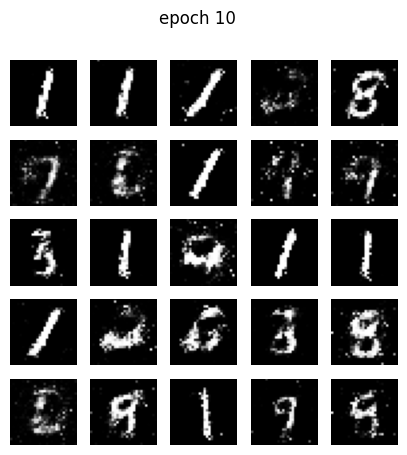

epoch=[11/50]  ,Disc Loss: 0.5787,  Gen loss: 1.7839
epoch=[12/50]  ,Disc Loss: 0.5139,  Gen loss: 1.9821
epoch=[13/50]  ,Disc Loss: 0.8588,  Gen loss: 1.2680
epoch=[14/50]  ,Disc Loss: 0.6941,  Gen loss: 1.7784
epoch=[15/50]  ,Disc Loss: 0.7545,  Gen loss: 2.0138
epoch=[16/50]  ,Disc Loss: 0.7262,  Gen loss: 2.2098
epoch=[17/50]  ,Disc Loss: 0.7359,  Gen loss: 2.0506
epoch=[18/50]  ,Disc Loss: 0.7445,  Gen loss: 2.3473
epoch=[19/50]  ,Disc Loss: 0.9479,  Gen loss: 2.1012
epoch=[20/50]  ,Disc Loss: 0.8160,  Gen loss: 1.5064


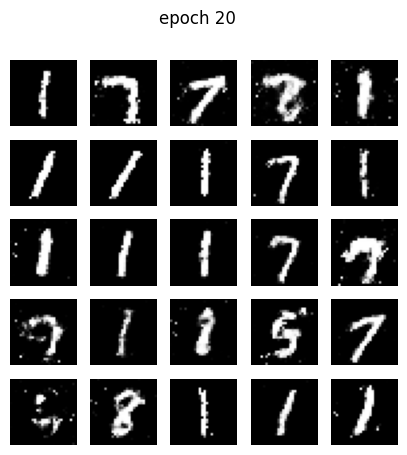

epoch=[21/50]  ,Disc Loss: 0.6203,  Gen loss: 2.4734
epoch=[22/50]  ,Disc Loss: 1.2412,  Gen loss: 1.9676
epoch=[23/50]  ,Disc Loss: 0.7601,  Gen loss: 2.2120
epoch=[24/50]  ,Disc Loss: 0.8068,  Gen loss: 1.4475
epoch=[25/50]  ,Disc Loss: 0.7969,  Gen loss: 1.9779
epoch=[26/50]  ,Disc Loss: 0.7568,  Gen loss: 1.7185
epoch=[27/50]  ,Disc Loss: 0.8132,  Gen loss: 1.8362
epoch=[28/50]  ,Disc Loss: 0.6981,  Gen loss: 1.6150
epoch=[29/50]  ,Disc Loss: 0.9123,  Gen loss: 1.8810
epoch=[30/50]  ,Disc Loss: 0.7377,  Gen loss: 1.8134


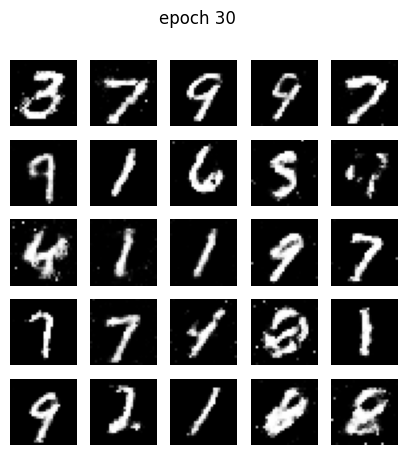

epoch=[31/50]  ,Disc Loss: 0.7909,  Gen loss: 1.1651
epoch=[32/50]  ,Disc Loss: 0.8502,  Gen loss: 1.8472
epoch=[33/50]  ,Disc Loss: 0.8058,  Gen loss: 1.3464
epoch=[34/50]  ,Disc Loss: 0.7840,  Gen loss: 1.7690
epoch=[35/50]  ,Disc Loss: 0.6866,  Gen loss: 2.1616
epoch=[36/50]  ,Disc Loss: 0.8851,  Gen loss: 1.3258
epoch=[37/50]  ,Disc Loss: 0.7901,  Gen loss: 1.2867
epoch=[38/50]  ,Disc Loss: 0.8113,  Gen loss: 1.6520
epoch=[39/50]  ,Disc Loss: 0.7575,  Gen loss: 1.9495
epoch=[40/50]  ,Disc Loss: 0.7757,  Gen loss: 1.6408


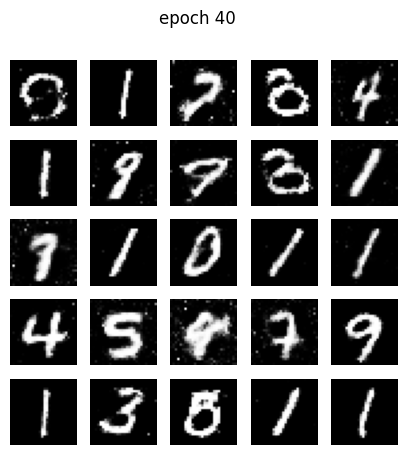

epoch=[41/50]  ,Disc Loss: 0.8623,  Gen loss: 1.3539
epoch=[42/50]  ,Disc Loss: 0.8057,  Gen loss: 1.4059
epoch=[43/50]  ,Disc Loss: 0.7674,  Gen loss: 1.9230
epoch=[44/50]  ,Disc Loss: 0.6969,  Gen loss: 1.4181
epoch=[45/50]  ,Disc Loss: 0.8206,  Gen loss: 1.5916
epoch=[46/50]  ,Disc Loss: 0.9397,  Gen loss: 1.3009
epoch=[47/50]  ,Disc Loss: 0.9916,  Gen loss: 1.5126
epoch=[48/50]  ,Disc Loss: 0.8805,  Gen loss: 1.6908
epoch=[49/50]  ,Disc Loss: 0.7942,  Gen loss: 1.5153
epoch=[50/50]  ,Disc Loss: 0.8468,  Gen loss: 2.2375


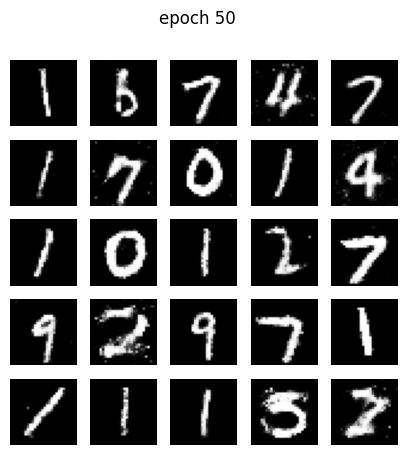

In [13]:
for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        real_labels = torch.ones(real_imgs.size(0),1).to(device)
        fake_labels = torch.zeros(real_imgs.size(0),1).to(device)

        optimizer_D.zero_grad()
        real_loss = criterion(discriminator(real_imgs), real_labels)
        z = torch.randn(real_imgs.size(0), latent_dim).to(device)
        fake_imgs = generator(z)

        fake_loss = criterion(discriminator(fake_imgs.detach()), fake_labels)
        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()
        optimizer_G.zero_grad()


        g_loss = criterion(discriminator(fake_imgs), real_labels)

        g_loss.backward()
        optimizer_G.step()

    print(f"epoch=[{epoch+1}/{epochs}]  ,Disc Loss: {d_loss.item():.4f},  Gen loss: {g_loss.item():.4f}")
    if (epoch+1) % 10 == 0:
        show_images(fake_imgs, epoch+1)

In [14]:
torch.save(generator.state_dict(), "generator.pth")

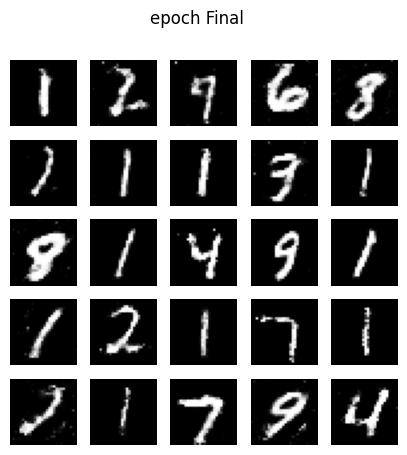

In [15]:
generator.eval()

z = torch.randn(25, latent_dim).to(device)
generated_imgs = generator(z)

show_images(generated_imgs, "Final")

**CGAN**

In [6]:
class cGenerator(nn.Module):
    def __init__(self, latent_dim, num_classes=10):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,512),
            nn.LeakyReLU(0.2),
            nn.Linear(512,1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024,784),
            nn.Tanh()
        )

    def forward(self, noise, label):
        l = self.label_emb(label)
        x = torch.cat((noise, l), -1)
        img = self.model(x)
        img = img.view(-1,1,28,28)
        return img

In [7]:
class cDiscriminator(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(784 + num_classes, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024,512),
            nn.LeakyReLU(0.2),
            nn.Linear(512,256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self, img, label):
        i = img.view(img.size(0), -1)
        label_input = self.label_emb(label)
        x = torch.cat((i, label_input), -1)
        o = self.model(x)
        return o

In [8]:
cgenerator = cGenerator(latent_dim).to(device)
cdiscriminator = cDiscriminator().to(device)

In [9]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(cgenerator.parameters(), lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(cdiscriminator.parameters(), lr=lr, betas=(beta1, beta2))

epoch [1/50] ,Disc Loss: 0.7257,  Gen loss: 1.3258
epoch [2/50] ,Disc Loss: 0.9535,  Gen loss: 1.8979
epoch [3/50] ,Disc Loss: 0.9443,  Gen loss: 1.1002
epoch [4/50] ,Disc Loss: 1.0725,  Gen loss: 1.5764
epoch [5/50] ,Disc Loss: 1.0227,  Gen loss: 0.9350
epoch [6/50] ,Disc Loss: 1.1339,  Gen loss: 1.0049
epoch [7/50] ,Disc Loss: 0.9848,  Gen loss: 1.5611
epoch [8/50] ,Disc Loss: 0.9917,  Gen loss: 1.4514
epoch [9/50] ,Disc Loss: 1.1915,  Gen loss: 1.7681
epoch [10/50] ,Disc Loss: 1.2017,  Gen loss: 1.1926


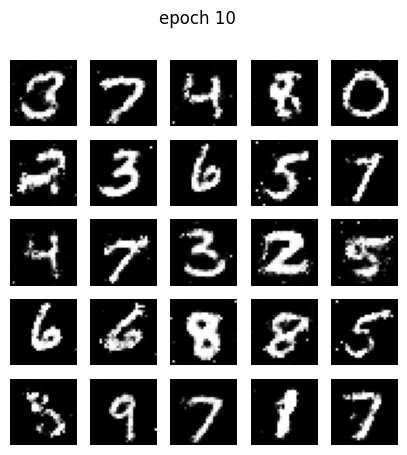

epoch [11/50] ,Disc Loss: 1.0510,  Gen loss: 1.2002
epoch [12/50] ,Disc Loss: 1.1447,  Gen loss: 1.6026
epoch [13/50] ,Disc Loss: 1.2762,  Gen loss: 0.4633
epoch [14/50] ,Disc Loss: 1.0597,  Gen loss: 1.3507
epoch [15/50] ,Disc Loss: 1.2531,  Gen loss: 1.5040
epoch [16/50] ,Disc Loss: 1.2276,  Gen loss: 1.1546
epoch [17/50] ,Disc Loss: 1.0607,  Gen loss: 1.5746
epoch [18/50] ,Disc Loss: 1.0978,  Gen loss: 1.0864
epoch [19/50] ,Disc Loss: 1.1697,  Gen loss: 1.2004
epoch [20/50] ,Disc Loss: 1.0492,  Gen loss: 1.0913


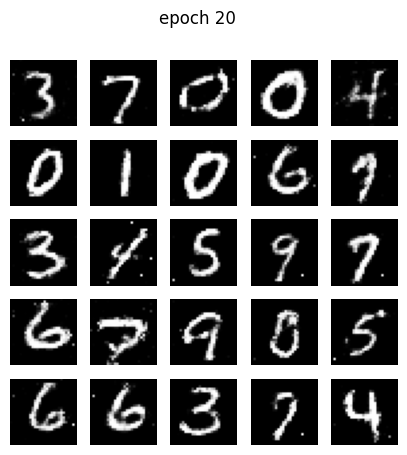

epoch [21/50] ,Disc Loss: 1.0184,  Gen loss: 0.8683
epoch [22/50] ,Disc Loss: 1.2109,  Gen loss: 0.9984
epoch [23/50] ,Disc Loss: 1.1199,  Gen loss: 1.1322
epoch [24/50] ,Disc Loss: 0.9985,  Gen loss: 1.2486
epoch [25/50] ,Disc Loss: 1.2519,  Gen loss: 1.7165
epoch [26/50] ,Disc Loss: 1.0485,  Gen loss: 1.1790
epoch [27/50] ,Disc Loss: 1.1034,  Gen loss: 1.0896
epoch [28/50] ,Disc Loss: 1.1102,  Gen loss: 0.9922
epoch [29/50] ,Disc Loss: 1.2420,  Gen loss: 0.9992
epoch [30/50] ,Disc Loss: 1.1866,  Gen loss: 1.4039


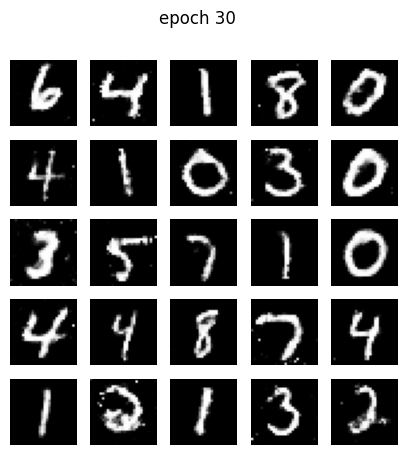

epoch [31/50] ,Disc Loss: 1.1725,  Gen loss: 1.3779
epoch [32/50] ,Disc Loss: 1.2891,  Gen loss: 1.0090
epoch [33/50] ,Disc Loss: 1.0323,  Gen loss: 1.1000
epoch [34/50] ,Disc Loss: 1.2416,  Gen loss: 1.5557
epoch [35/50] ,Disc Loss: 1.1082,  Gen loss: 0.8213
epoch [36/50] ,Disc Loss: 1.2781,  Gen loss: 1.2880
epoch [37/50] ,Disc Loss: 1.1048,  Gen loss: 1.0186
epoch [38/50] ,Disc Loss: 1.0964,  Gen loss: 1.2027
epoch [39/50] ,Disc Loss: 1.1385,  Gen loss: 0.7068
epoch [40/50] ,Disc Loss: 1.1531,  Gen loss: 1.0177


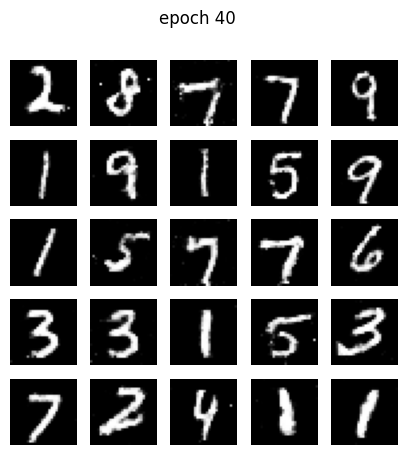

epoch [41/50] ,Disc Loss: 1.1456,  Gen loss: 1.2865
epoch [42/50] ,Disc Loss: 1.1370,  Gen loss: 1.5006
epoch [43/50] ,Disc Loss: 1.1620,  Gen loss: 0.9670
epoch [44/50] ,Disc Loss: 1.1346,  Gen loss: 1.2058
epoch [45/50] ,Disc Loss: 1.0964,  Gen loss: 1.3797
epoch [46/50] ,Disc Loss: 1.1178,  Gen loss: 1.2142
epoch [47/50] ,Disc Loss: 1.1905,  Gen loss: 1.2666
epoch [48/50] ,Disc Loss: 1.1843,  Gen loss: 1.3568
epoch [49/50] ,Disc Loss: 1.2149,  Gen loss: 1.1096
epoch [50/50] ,Disc Loss: 1.0737,  Gen loss: 1.0647


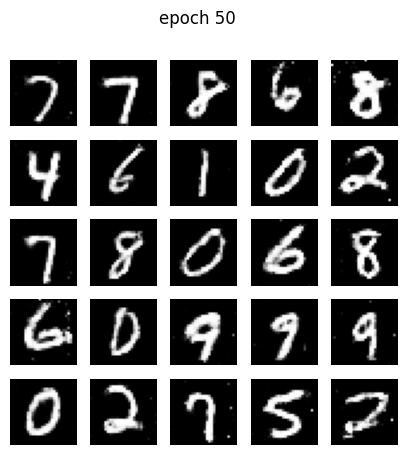

In [12]:
for epoch in range(epochs):
    for i, (real_imgs, labels) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        batch_size_curr = real_imgs.size(0)
        real_targets = torch.ones(batch_size_curr, 1).to(device)
        fake_targets = torch.zeros(batch_size_curr, 1).to(device)

        optimizer_D.zero_grad()
        real_loss = criterion(
            cdiscriminator(real_imgs, labels),
            real_targets
        )
        z = torch.randn(batch_size_curr, latent_dim).to(device)

        fake_imgs = cgenerator(z, labels)

        fake_loss = criterion(
            cdiscriminator(fake_imgs.detach(), labels),
            fake_targets
        )
        d_loss = real_loss + fake_loss
        d_loss.backward()

        optimizer_D.step()
        optimizer_G.zero_grad()
        z = torch.randn(batch_size_curr, latent_dim).to(device)
        fake_imgs = cgenerator(z, labels)

        g_loss = criterion(
            cdiscriminator(fake_imgs, labels),
            real_targets
        )

        g_loss.backward()
        optimizer_G.step()


    print(f"epoch [{epoch+1}/{epochs}] ,Disc Loss: {d_loss.item():.4f},  Gen loss: {g_loss.item():.4f}")

    if (epoch+1) % 10 == 0:
        show_images(fake_imgs, epoch+1)

In [13]:
torch.save(cgenerator.state_dict(), "cgenerator.pth")

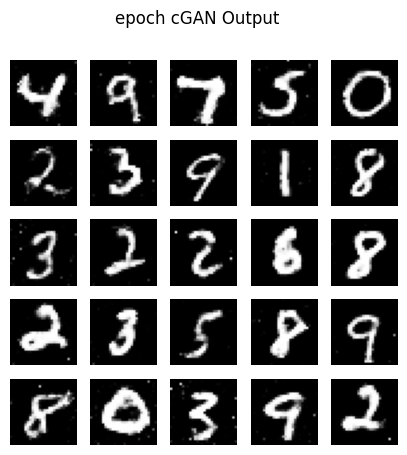

In [14]:
cgenerator.eval()

z = torch.randn(25, latent_dim).to(device)
labels = torch.randint(0, 10, (25,)).to(device)

generated_imgs = cgenerator(z, labels)
show_images(generated_imgs, "cGAN Output")

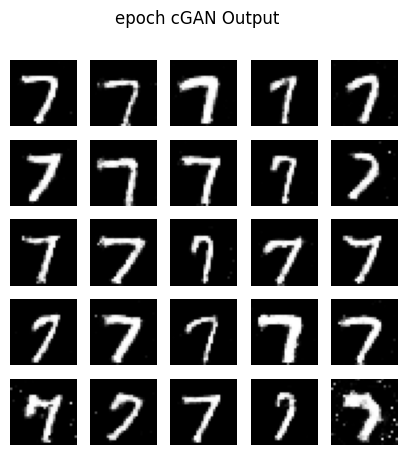

In [16]:
z = torch.randn(25, latent_dim).to(device)
label = torch.full((25,), 7).to(device)

gen_i = cgenerator(z, label)
show_images(gen_i, "cGAN Output")